In [1]:
#Import libraries and specify paths

import pandas as pd
import numpy  as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Librarties imported")

train_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_train.csv"
test_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_test.csv"

print("Paths are set")

Librarties imported
Paths are set


In [2]:
#load train and test data

train_df=pd.read_csv(train_csv)
test_df=pd.read_csv(test_csv)

print(f"Train CSV: {train_df.shape}")
print(f"Test CSV: {test_df.shape}")

print(f"\nTrain label Distribution: {train_df['label'].value_counts().to_dict()}")
print(f"\nTest label Distribution: {test_df['label'].value_counts().to_dict()}")

Train CSV: (24482, 104)
Test CSV: (7061, 104)

Train label Distribution: {0: 12241, 1: 12241}

Test label Distribution: {0: 4000, 1: 3061}


In [3]:
#Separate features and label

feature_columns=[feature for feature in train_df.columns if feature!='label']

X_train=train_df[feature_columns]
y_train=train_df['label']

X_test=test_df[feature_columns]
y_test=test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

X_train shape: (24482, 103)
X_test shape: (7061, 103)
y_train distribution: {0: 12241, 1: 12241}
y_test distribution: {0: 4000, 1: 3061}


In [4]:
# Definition of all models

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

print("Models Defined:")
for i in models:
    print(i)

Models Defined:
Decision Tree
Random Forest
KNN
SVM
Logistic Regression
XGBoost


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cross_validation_results=[]

print("Running 5-fold Cross-validation on training set....")

for model_name, model in models.items():
    print(f"Cross Validating {model_name}....")

    cross_validadtion_scores=cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")

    cross_validation_results.append({
        "Model": model_name,
        "CV Mean F1": round(cross_validadtion_scores.mean(),4),
        "CV Std F1": round(cross_validadtion_scores.std(),4),
        "CV Min F1": round(cross_validadtion_scores.min(),4),
        "CV Max F1": round(cross_validadtion_scores.max(),4)
    })

    print(f"Fold Scores: {[round(s,4) for s in cross_validadtion_scores]}")
    print(f"Mean F1: {cross_validadtion_scores.mean()}")
    print(f"\nStd F1: {cross_validadtion_scores.std()}")

cross_validation_results_df=pd.DataFrame(cross_validation_results)
cross_validation_results_df=cross_validation_results_df.sort_values('CV Mean F1', ascending =False).reset_index(drop=True)
print("Cross Validation Results:\n")
print(cross_validation_results_df.to_string(index=False))

Running 5-fold Cross-validation on training set....
Cross Validating Decision Tree....
Fold Scores: [np.float64(0.9483), np.float64(0.9534), np.float64(0.9478), np.float64(0.9453), np.float64(0.9568)]
Mean F1: 0.9503122552841028

Std F1: 0.004172207763457652
Cross Validating Random Forest....
Fold Scores: [np.float64(0.9555), np.float64(0.9601), np.float64(0.9575), np.float64(0.9578), np.float64(0.9691)]
Mean F1: 0.9599719499136479

Std F1: 0.00477303534171529
Cross Validating KNN....
Fold Scores: [np.float64(0.936), np.float64(0.9418), np.float64(0.9354), np.float64(0.9339), np.float64(0.9416)]
Mean F1: 0.9377348558030553

Std F1: 0.003314053500896057
Cross Validating SVM....
Fold Scores: [np.float64(0.8649), np.float64(0.8662), np.float64(0.8619), np.float64(0.8667), np.float64(0.8733)]
Mean F1: 0.8666030191081948

Std F1: 0.00373071828639578
Cross Validating Logistic Regression....
Fold Scores: [np.float64(0.8485), np.float64(0.8396), np.float64(0.8472), np.float64(0.8396), np.float

In [ ]:
#Train and evaluate all models
import time
results=[]

for model_name, model in models.items():
    print(f"Training {model_name}....")

    #train the model on train data
    start_time=time.time()
    model.fit(X_train, y_train)
    end_time=time.time()
    training_time=end_time-start_time

    #predict on test data
    start_time=time.time()
    y_pred=model.predict(X_test)
    end_time=time.time()
    testing_time=end_time-start_time
    
    #metrics calculation
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    #Storing results
    results.append({
         'Model': model_name,
         'Accuracy': round(accuracy,4),
         'Precision': round(precision,4),
         'Recall': round(recall,4),
         'F1-Score': round(f1,4),
         'Training Time (S)': training_time,
         'Testing Time (S)': testing_time
     })
    print(f"Model Name: {model_name}")
    print(f"Accuracy {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Training Time: {training_time} seconds")
    print(f"Testing Time: {testing_time} seconds")


print("\n All models are trained and evaluated")       
    

In [8]:
results_df=pd.DataFrame(results)

results_df=results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("UQ-IoT Dataset Model Comparision:")
print(results_df.to_string(index=False))

UQ-IoT Dataset Model Comparision:
              Model  Accuracy  Precision  Recall  F1-Score
            XGBoost    0.9640     0.9621  0.9546    0.9583
      Random Forest    0.9630     0.9557  0.9592    0.9574
      Decision Tree    0.9552     0.9507  0.9458    0.9482
                KNN    0.9451     0.9459  0.9262    0.9360
                SVM    0.8749     0.9054  0.7945    0.8464
Logistic Regression    0.8604     0.8867  0.7772    0.8283


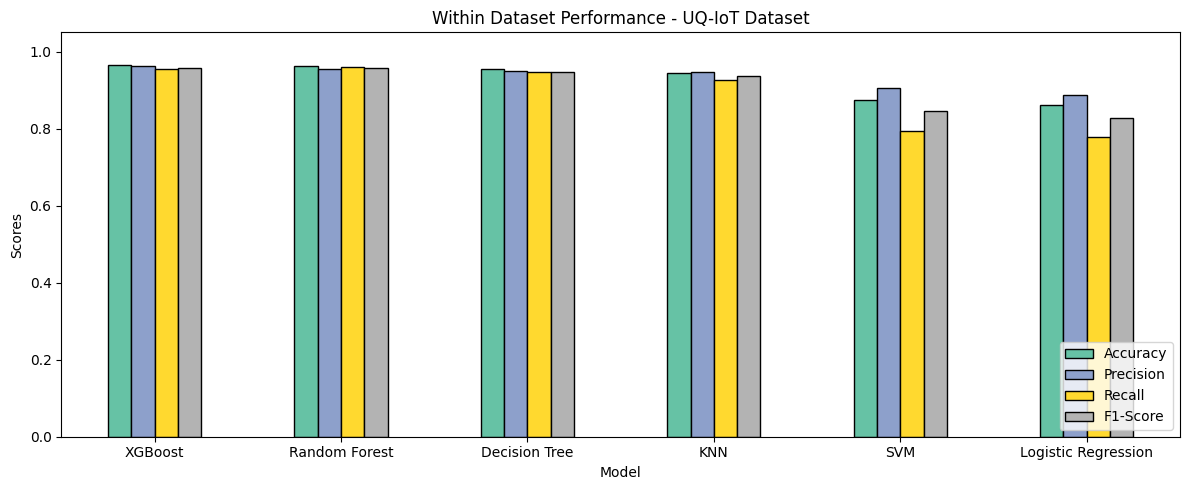

In [9]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].copy()
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    colormap="Set1",
    edgecolor="black"
)

plt.title("Within Dataset Performance - UQ-IoT Dataset")
plt.xlabel("Model")
plt.ylabel("Scores")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
# Feature Importance

rf = models['Random Forest']
xgb = models['XGBoost']

rf_importance= pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 20 features - Random Forest:")
print(rf_importance.head(20).to_string(index=False))

print("\nTop 20 features - XGBoost:")
print(xgb_importance.head(20).to_string(index=False))

common_top20_features = set(xgb_importance.head(20)['Feature']) & set(rf_importance.head(20)['Feature'])
for feature in common_top20_features:
    print(feature)

Top 20 features - Random Forest:
              Feature  Importance
   HH_0.01_radius_0_1    0.073737
      MI_dir_0.01_std    0.054436
        HH_0.01_std_0    0.041664
    HH_0.1_radius_0_1    0.040044
       MI_dir_0.1_std    0.038176
      HH_1_radius_0_1    0.030030
         HH_0.1_std_0    0.026160
   HH_jit_0.01_weight    0.025765
   MI_dir_0.01_weight    0.022314
     HH_jit_0.01_mean    0.022002
      HH_jit_0.01_std    0.020841
    HH_jit_0.1_weight    0.019694
 HpHp_0.01_radius_0_1    0.018299
     HH_0.01_weight_0    0.018227
      HH_3_radius_0_1    0.017354
  HpHp_0.1_radius_0_1    0.016941
HH_0.01_magnitude_0_1    0.016890
      HH_jit_1_weight    0.016818
      HH_jit_0.1_mean    0.016142
     MI_dir_0.01_mean    0.015809

Top 20 features - XGBoost:
                 Feature  Importance
      HH_0.01_radius_0_1    0.285239
        HpHp_0.01_mean_0    0.043581
      HH_jit_0.01_weight    0.041071
            HH_0.1_std_0    0.031698
      MI_dir_0.01_weight    0.031437
   

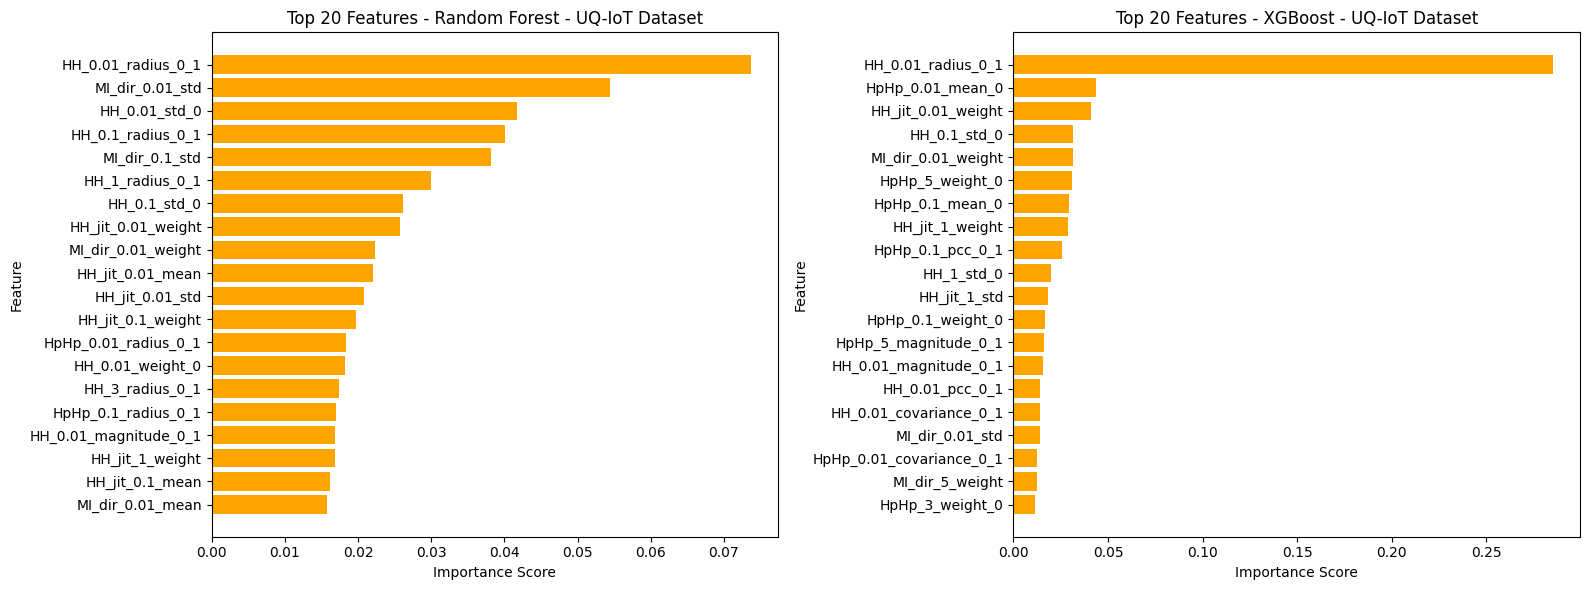

In [11]:
#plot top-20 features
import matplotlib.pyplot as plt

fig, axes=plt.subplots(1,2,figsize=(16,6))

top20_rf=rf_importance.head(20)
axes[0].barh(top20_rf['Feature'][::-1], top20_rf['Importance'][::-1], color='orange')
axes[0].set_title('Top 20 Features - Random Forest - UQ-IoT Dataset')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Feature')

top20_xgb=xgb_importance.head(20)
axes[1].barh(top20_xgb['Feature'][::-1], top20_xgb['Importance'][::-1], color='orange')
axes[1].set_title('Top 20 Features - XGBoost - UQ-IoT Dataset')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()